Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('Datasets/StudentsPerformance.csv')
    print("Data Loaded Successfully.")
except FileNotFoundError:
    print("Error: 'StudentsPerformance.csv' not found. Please ensure it is in the same folder.")

print(f"Data Shape: {df.shape}")
print("\nData Types & Memory Usage:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nCardinality")
print(df.nunique())

Data Loaded Successfully.
Data Shape: (1000, 8)

Data Types & Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Descriptive Statistics:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600

Missing Value Analysis

Missing Value Percentages:
gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64
Figure saved: 'missing_values.png'


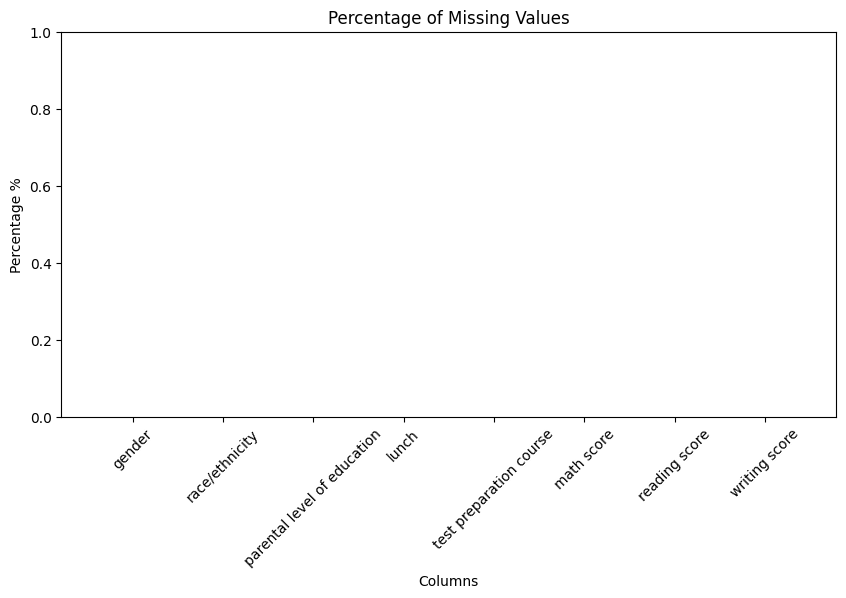

No missing values to impute in: gender
No missing values to impute in: race/ethnicity
No missing values to impute in: parental level of education
No missing values to impute in: lunch
No missing values to impute in: test preparation course
No missing values to impute in: math score
No missing values to impute in: reading score
No missing values to impute in: writing score


In [7]:
missing_percent = df.isnull().mean() * 100

print("Missing Value Percentages:")
print(missing_percent)

plt.figure(figsize=(10, 5))
plt.bar(missing_percent.index, missing_percent.to_numpy(), color='pink')
plt.title('Percentage of Missing Values')
plt.ylabel('Percentage %')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.ylim(0, max(1, missing_percent.max() + 1))
plt.savefig('Images/missing_values.png', bbox_inches='tight')
print("Figure saved: 'missing_values.png'")
plt.show()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())
        print(f"Imputed missing values in column: {col}")
    else:
        print(f"No missing values to impute in: {col}")

Column Selection And Filtering

In [8]:
df1 = df.loc[(df['math score'] > 80) & (df['reading score'] > 80) & (df['writing score'] > 80)]
print(df1)

df2 = df.iloc[:10, :4]
print(df2)

df3 = df[df['parental level of education'].str.contains('associate')]
print(df3)

df4 = df[df['race/ethnicity'].str.startswith('group A')]
print(df4)

df5 = df[df['parental level of education'].str.endswith('high school')]
print(df5)

df6 = df[(df['reading score'] >= 60) | (df['writing score'] >= 60)]
print(df6)

     gender race/ethnicity parental level of education     lunch  \
2    female        group B             master's degree  standard   
6    female        group B                some college  standard   
16     male        group C                 high school  standard   
34     male        group E                some college  standard   
49     male        group C                 high school  standard   
..      ...            ...                         ...       ...   
957  female        group D             master's degree  standard   
962  female        group E          associate's degree  standard   
970  female        group D           bachelor's degree  standard   
979  female        group C          associate's degree  standard   
995  female        group E             master's degree  standard   

    test preparation course  math score  reading score  writing score  
2                      none          90             95             93  
6                 completed          88

Feature Engineering

In [9]:
print("Before Feature Engineering:\n")
print(df[['math score', 'reading score', 'writing score', 'lunch']].head())

df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

df['grade'] = pd.cut(df['average_score'],
                     bins=[0, 60, 70, 80, 90, 100],
                     labels=['F', 'D', 'C', 'B', 'A'])

df['math_status'] = np.where(df['math score'] >= 60, 'Pass', 'Fail')

df['lunch_short'] = df['lunch'].str.extract(r'^(\w+)')

df['score_spread'] = df[['math score', 'reading score', 'writing score']].max(axis=1) - \
                     df[['math score', 'reading score', 'writing score']].min(axis=1)

print("\nAfter Feature Engineering:\n")
print(df[['math score', 'average_score', 'grade', 'math_status', 'lunch', 'lunch_short']].head())

Before Feature Engineering:

   math score  reading score  writing score         lunch
0          72             72             74      standard
1          69             90             88      standard
2          90             95             93      standard
3          47             57             44  free/reduced
4          76             78             75      standard

After Feature Engineering:

   math score  average_score grade math_status         lunch lunch_short
0          72      72.666667     C        Pass      standard    standard
1          69      82.333333     B        Pass      standard    standard
2          90      92.666667     A        Pass      standard    standard
3          47      49.333333     F        Fail  free/reduced        free
4          76      76.333333     C        Pass      standard    standard


Grouping and Pivot Tables

Ethnicity Grouping:

                     mean        min         max        std  count
race/ethnicity                                                    
group A         62.992509  23.333333   96.333333  14.444598     89
group B         65.468421  18.333333   96.666667  14.732133    190
group C         67.131661   9.000000   98.666667  13.872211    319
group D         69.179389  31.000000   99.000000  13.252776    262
group E         72.752381  26.000000  100.000000  14.565016    140

Math Score Pivot:

gender                          female       male
parental level of education                      
associate's degree           65.250000  70.764151
bachelor's degree            68.349206  70.581818
high school                  59.351064  64.705882
master's degree              66.500000  74.826087
some college                 65.406780  69.009259
some high school             59.296703  67.840909


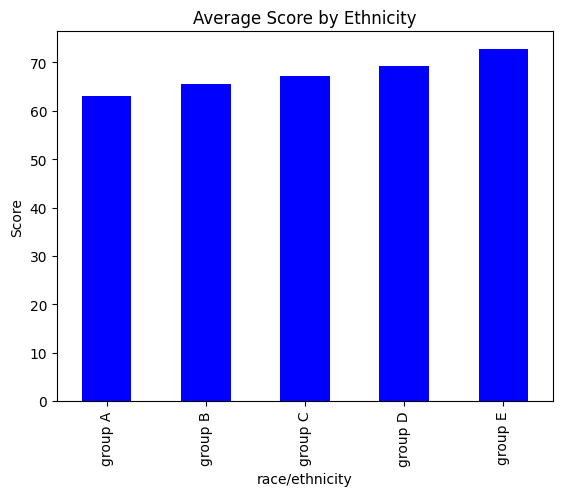

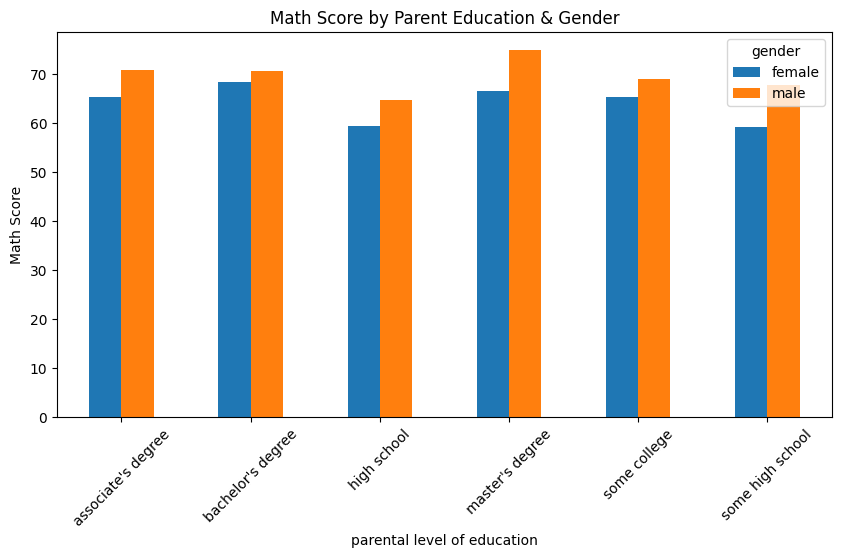

In [10]:
df7 = df.groupby('race/ethnicity')['average_score'].agg(['mean', 'min', 'max', 'std', 'count'])
print("Ethnicity Grouping:\n")
print(df7)

df8 = df.pivot_table(values='math score',
                       index='parental level of education',
                       columns='gender',
                       aggfunc='mean')

print("\nMath Score Pivot:\n")
print(df8)

df7['mean'].plot(kind='bar', color='blue', title='Average Score by Ethnicity')
plt.ylabel('Score')
plt.savefig('Images/grouped.png')
plt.show()

df8.plot(kind='bar', figsize=(10,5), title='Math Score by Parent Education & Gender')
plt.ylabel('Math Score')
plt.xticks(rotation=45)
plt.savefig('Images/pivot.png')
plt.show()

Sorting and Ranking

In [11]:
df9 = df.sort_values(by=['math score', 'reading score'], ascending=[False, False])

df['rank_dense'] = df['average_score'].rank(method='dense', ascending=False)
df['rank_average'] = df['average_score'].rank(method='average', ascending=False)
df['rank_first'] = df['average_score'].rank(method='first', ascending=False)

print("Top 10 Students:\n")
print(df9[['gender', 'math score', 'reading score', 'average_score']].head(10))

print("\nBottom 10 Students:\n")
print(df9[['gender', 'math score', 'reading score', 'average_score']].tail(10))

Top 10 Students:

     gender  math score  reading score  average_score
149    male         100            100      97.666667
458  female         100            100     100.000000
916    male         100            100     100.000000
962  female         100            100     100.000000
625    male         100             97      98.666667
623    male         100             96      94.000000
451  female         100             92      96.333333
114  female          99            100      99.666667
263  female          99             93      94.000000
306    male          99             87      89.000000

Bottom 10 Students:

     gender  math score  reading score  average_score
91     male          27             34      32.333333
363  female          27             34      31.000000
466  female          26             31      31.666667
338  female          24             38      29.666667
842  female          23             44      34.333333
145  female          22             39    

String Operations

In [12]:
df10 = df.select_dtypes(include=['object']).columns

for col in df10:
    df[col] = df[col].str.strip().str.lower()

df['gender_num'] = df['gender'].str.extract(r'^(\w)')

df['race_num'] = df['race/ethnicity'].str.extract(r'group (\w)')

df['edu_type'] = df['parental level of education'].str.extract(r'(\w+)$')

df['lunch_num'] = df['lunch'].str.extract(r'^(\w+)')

df['prep_num'] = df['test preparation course'].str.extract(r'(^.{4})')

print("Regex:")
print("\nGender:")
print(df['gender_num'].value_counts())

print("\nRace:")
print(df['race_num'].value_counts())

print("\nEducation:")
print(df['edu_type'].value_counts())

print("\nLunch:")
print(df['lunch_num'].value_counts())

print("\nPrep Course:")
print(df['prep_num'].value_counts())

Regex:

Gender:
gender_num
f    518
m    482
Name: count, dtype: int64

Race:
race_num
c    319
d    262
b    190
e    140
a     89
Name: count, dtype: int64

Education:
edu_type
degree     399
school     375
college    226
Name: count, dtype: int64

Lunch:
lunch_num
standard    645
free        355
Name: count, dtype: int64

Prep Course:
prep_num
none    642
comp    358
Name: count, dtype: int64


Data Export For Cleaned Dataset

In [13]:
df.to_csv('Results/StudentsPerformance_Cleaned.csv', index=False)

with pd.ExcelWriter('Results/Summary_Tables.xlsx') as writer:
    df7.to_excel(writer, sheet_name='Grouped_Stats')

Combine 2 Datasets

In [14]:
if 'est_parent_salary' in df.columns:
    df = df.drop(columns=['est_parent_salary'])
    print("Cleaned existing salary data to prevent duplicate columns.")
df_salary_raw = pd.read_csv('Datasets/Salary_Data.csv')
df_salary_raw['Education Level'] = df_salary_raw['Education Level'].str.lower().str.strip()

education_map = {
    "bachelor's": "bachelor's degree",
    "master's": "master's degree",
    "phd": "master's degree",
    "high school": "high school"
}
df_salary_raw['matched_education'] = df_salary_raw['Education Level'].map(education_map)

salary_df = df_salary_raw.groupby('matched_education')['Salary'].mean().reset_index()
salary_df.rename(columns={'matched_education': 'parental level of education',
                          'Salary': 'est_parent_salary'}, inplace=True)

df_inner = pd.merge(df, salary_df, on='parental level of education', how='inner')
df_left = pd.merge(df, salary_df, on='parental level of education', how='left')

print(f"Original Student Count: {len(df)}")
print(f"Inner Join Count:       {len(df_inner)}")
print(f"Left Join Count:        {len(df_left)}")

df_ABCD = df_left.copy()
global_avg_salary = df_salary_raw['Salary'].mean()
df_ABCD['est_parent_salary'] = df_ABCD['est_parent_salary'].fillna(global_avg_salary)

Original Student Count: 1000
Inner Join Count:       373
Left Join Count:        1000


Outlier Detection

Math Outlier Limits: < 27.00 or > 107.00
Number of Outliers detected: 8


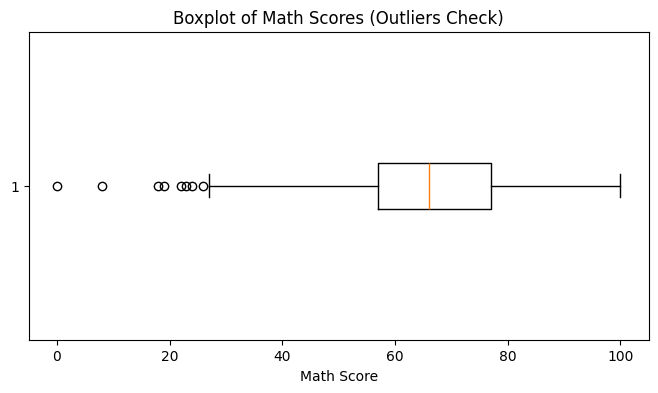

In [15]:
Q1 = df_ABCD['math score'].quantile(0.25)
Q3 = df_ABCD['math score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_ABCD[(df_ABCD['math score'] < lower_bound) | (df_ABCD['math score'] > upper_bound)]
print(f"Math Outlier Limits: < {lower_bound:.2f} or > {upper_bound:.2f}")
print(f"Number of Outliers detected: {len(outliers)}")

plt.figure(figsize=(8, 4))
plt.boxplot(df_ABCD['math score'], vert=False)
plt.title('Boxplot of Math Scores (Outliers Check)')
plt.xlabel('Math Score')
plt.savefig('Images/math_outliers.png')
plt.show()

df_ABCD['math score clean'] = np.where(df_ABCD['math score'] < lower_bound, lower_bound,
                                       np.where(df_ABCD['math score'] > upper_bound, upper_bound, df_ABCD['math score']))

Correlation Analysis

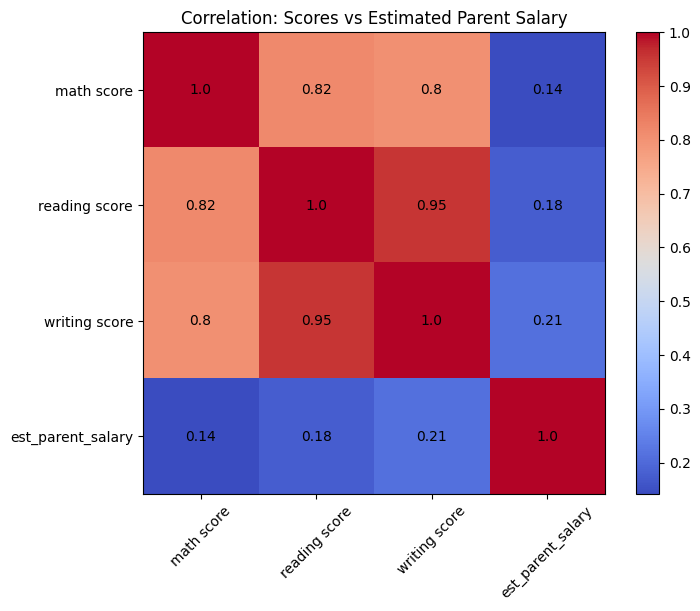

Correlation Matrix:
                    math score  reading score  writing score  est_parent_salary
math score           1.000000       0.817580       0.802642           0.141152
reading score        0.817580       1.000000       0.954598           0.177542
writing score        0.802642       0.954598       1.000000           0.214337
est_parent_salary    0.141152       0.177542       0.214337           1.000000


In [16]:
corr_cols = ['math score', 'reading score', 'writing score', 'est_parent_salary']
corr_matrix = df_ABCD[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
fig.colorbar(cax)

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation: Scores vs Estimated Parent Salary')

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        text = ax.text(j, i, round(val, 2),
                       ha="center", va="center", color="black")

plt.savefig('Images/correlation.png', bbox_inches='tight')
plt.show()

print("Correlation Matrix:\n", corr_matrix)

Distribution Analysis

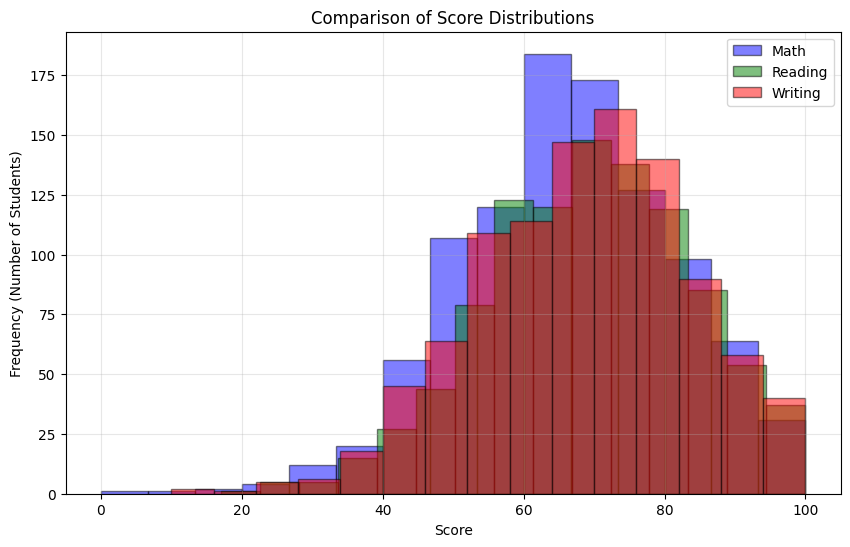

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(df['math score'], alpha=0.5, label='Math', bins=15, color='blue', edgecolor='black')
plt.hist(df['reading score'], alpha=0.5, label='Reading', bins=15, color='green', edgecolor='black')
plt.hist(df['writing score'], alpha=0.5, label='Writing', bins=15, color='red', edgecolor='black')

plt.legend(loc='upper right')
plt.title('Comparison of Score Distributions')
plt.xlabel('Score')
plt.ylabel('Frequency (Number of Students)')
plt.grid(True, alpha=0.3)

plt.savefig('Images/score_distributions.png')

plt.show()